# Metaheuristic Enhanced Model for Financial Markets

This notebook combines **Feature Selection** and **Feature Engineering** using Genetic Algorithms to enhance machine learning models for financial market trend prediction. 

## Workflow Overview:

0. **Settings**
1. **Installs and Imports**
2. **Data Cleaning**
3. **Baseline Feature Engineering** 
4. **Data Preprocessing** (80% train, 10% validation, 10% test)
5. **Baseline Model Training and Hyperparameter Tuning** (tune on train, evaluate on validation)
6. **Second Baseline: Top 50% Feature Models** (tuned params on reduced features, evaluate on validation)
7. **Feature Selection using Genetic Algorithm (GA)**
8. **Feature Engineering using Genetic Algorithm (GA)**
9. **Enhanced Model Training** (GA features + engineered features + baseline tuned params, train on train+val, test on test)
10. **Three-Model Comparison** (Tuned Baseline vs Top 50% vs GA Enhanced)
11. **Save Results and Metadata**


## 0. Settings


In [31]:
DATASET = 'XAUUSD_H1.csv'
VOLUME_TYPE_TICKER = True  # Set to true if the volume type is not the trading volume but the tick volume

## 1. Installs and Imports

First we install the requirements for the notebook and import the libraries

In [32]:
# Install dependencies from requirements.txt
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [33]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import time
import pickle
import json

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical and mathematical tools
from scipy import stats

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Import our custom modules
from MH_Feature_Selection import GeneticAlgorithm
from MH_Feature_Engineering import engineer_adaptive_moving_average, engineer_fractal_dimension_indicator

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

# For reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print("Custom metaheuristics modules loaded!")
print("Baseline feature engineering module will be imported when needed!")

All libraries imported successfully!
Custom metaheuristics modules loaded!
Baseline feature engineering module will be imported when needed!


### 1.1 Store Notebook Data

All the outputs and settings of various models in the notebook are stored in a timestamped folder for statistical comparisons later.

In [34]:
# Create timestamped directory for this run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_directory = f"run_{timestamp}"
os.makedirs(run_directory, exist_ok=True)

print(f"Created run directory: {run_directory}")

# Create a README file to document this run
readme_content = f"""# Combined Metaheuristics Workflow Run
Run Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Timestamp: {timestamp}

## Workflow Components:
1. Data Loading and Cleaning
2. Baseline Feature Engineering  
3. Data Preprocessing (Time-series splits: 80% train, 10% val, 10% test)
4. Baseline Model Training with Hyperparameter Tuning (tune on train, evaluate on val)
5. Second Baseline: Tuned models with top 50% most important features
6. GA Feature Selection
7. GA Feature Engineering (AMA, FDI)
8. Enhanced Model Training (GA selected + engineered features + baseline tuned params, train on train+val, test on test)
9. Three-way Performance Comparison
10. Results Saving

## Model Types Compared:
- **Tuned Baseline**: Hyperparameter-tuned models on all features (evaluated on validation set)
- **Tuned Baseline Top 50%**: Hyperparameter-tuned models on top 50% features (evaluated on validation set)  
- **GA Enhanced**: GA-selected features + engineered features + baseline tuned params (evaluated on test set)

## Files in this directory:
- *_baseline_tuned.pkl: Tuned baseline models (all features)
- *_baseline_top50.pkl: Tuned baseline models (top 50% features)
- *_enhanced.pkl: GA-enhanced models
- selected_features_*.pkl: GA-selected feature subsets
- engineered_features_*.pkl: GA-engineered features
- *_baseline_best_params.json: Best hyperparameters for baseline models
- *_baseline_top_features.pkl: Top 50% features for each model
- X_*_scaled.pkl: Preprocessed data splits
- y_*.pkl: Target variable splits
- feature_names.pkl: Original feature names
- performance_comparison.csv: All model results
- baseline_comparisons.csv: Baseline vs baseline top 50% comparisons
- enhanced_comparisons.csv: Top 50% vs GA enhanced comparisons
- *_importance.csv: Feature importance rankings
- three_model_comparison.png: Performance visualization
- README.txt: This file
"""

with open(os.path.join(run_directory, 'README.txt'), 'w') as f:
    f.write(readme_content)

print("Run documentation created!")

Created run directory: run_20251110_103002
Run documentation created!


### 1.2 Fetch Data
If a specific dataset is provided then that dataset will be used
If a specific ticker is provided, then we will first check if any data exists locally for that ticker. 
    If not, then data is downloaded.
    If yes, then that dataset is first updated to ensure the latest hours data in in the dataset.

In [35]:
print("Loading provided dataset...")
data = pd.read_csv(f'raw_data/{DATASET}')
print(f"Loaded data shape: {data.shape}")

print(f"Final data shape: {data.shape}")

Loading provided dataset...


Loaded data shape: (99999, 6)
Final data shape: (99999, 6)


## 2. Data cleaning
- Handle missing values with fill forward and fill backward
- Handle infinite values by replacing with NaN and filling
- Remove any remaining Nan rows

In [36]:
# Data cleaning and validation
print("Performing data cleaning...")

# Check for missing values
missing_values = data.isnull().sum()
print(f"\nMissing values per column:")
print(missing_values[missing_values > 0])

# Check for infinite values
numeric_cols = data.select_dtypes(include=[np.number]).columns
inf_values = np.isinf(data[numeric_cols]).sum()
print(f"\nInfinite values per column:")
print(inf_values[inf_values > 0])

# Handle missing values by forward fill and backward fill
'''
if missing_values.sum() > 0:
    print(f"Filling {missing_values.sum()} missing values...")
    data = data.fillna(method='ffill').fillna(method='bfill')

# Handle infinite values by replacing with NaN and then filling
if inf_values.sum() > 0:
    print(f"Replacing {inf_values.sum()} infinite values...")
    data[numeric_cols] = data[numeric_cols].replace([np.inf, -np.inf], np.nan)
    data = data.fillna(method='ffill').fillna(method='bfill')
'''

# Remove any remaining NaN rows
initial_rows = len(data)
data = data.dropna()
dropped_rows = initial_rows - len(data)
if dropped_rows > 0:
    print(f"Dropped {dropped_rows} rows with remaining NaN values")

print(f"\nCleaned data shape: {data.shape}")
print("Data cleaning completed!")

Performing data cleaning...

Missing values per column:
Series([], dtype: int64)

Infinite values per column:
Series([], dtype: int64)

Cleaned data shape: (99999, 6)
Data cleaning completed!

Cleaned data shape: (99999, 6)
Data cleaning completed!


In [37]:
# Rename columns to match required OHLCV format
data.columns = ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume']

# Parse datetime if present (adjust column name as needed)
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data = data.set_index('Date')
elif 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data = data.set_index('Datetime')
elif 'Timestamp' in data.columns:
    data['Timestamp'] = pd.to_datetime(data['Timestamp'])
    data = data.set_index('Timestamp')

print(f"Data date range: {data.index[0]} to {data.index[-1]}")

# Display basic statistics for OHLCV data
print("\nOHLCV basic statistics:")
print(data[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

Data date range: 2009-03-11 09:00:00 to 2025-11-10 06:00:00

OHLCV basic statistics:
               Open          High           Low         Close        Volume
count  99999.000000  99999.000000  99999.000000  99999.000000  99999.000000
mean    1605.076546   1607.202411   1602.904100   1605.107159     59.271173
std      537.125092    538.062776    536.177149    537.180913      5.451122
min      865.585000    866.942000    864.329000    865.561000      1.000000
25%     1247.094000   1248.537000   1245.666000   1247.105000     60.000000
50%     1431.008000   1432.853000   1429.256000   1431.047000     60.000000
75%     1808.096500   1809.996500   1806.111500   1808.146500     60.000000
max     4377.885000   4381.298000   4358.948000   4377.848000     75.000000


## 2.2 Date Range
Set a daterange to be used
In this case; 6 months of data + 100 hours to account for lookback windows

In [38]:
# Define the date range or number of months for filtering
# Use the last N months of data plus 
months_to_use = 6
end_date_dynamic = data.index.max()
start_date_dynamic = end_date_dynamic - timedelta(days=months_to_use * 30)

# add a buffer of 100 hours to account for lookback periods in feature engineering
start_date_dynamic -= timedelta(hours=100)

# Filter the data based on the chosen option
#filtered_data = data.loc[start_date:end_date]  # Use this for specific date range
filtered_data = data.loc[start_date_dynamic:end_date_dynamic]  # Use this for last N months

print(f"Filtered data shape: {filtered_data.shape}")
print(f"Filtered data date range: {filtered_data.index.min()} to {filtered_data.index.max()}")

Filtered data shape: (2988, 5)
Filtered data date range: 2025-05-11 22:00:00 to 2025-11-10 06:00:00


## 3. Baseline Feature Engineering

Apply comprehensive feature engineering to create technical indicators and the target variable from raw OHLCV data.

In [39]:
# Import the baseline feature engineering function
from MH_feature_engineering_baseline import compute_baseline_features, compute_target_rule

print("Creating comprehensive technical indicators using the baseline feature engineering module...")

# Use the modularized feature engineering function
feature_df = compute_baseline_features(filtered_data, volume_type_ticker=VOLUME_TYPE_TICKER)

print(f"Baseline feature engineering completed!")
print(f"Generated {len([col for col in feature_df.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']])} technical indicators")
print("Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical")

Creating comprehensive technical indicators using the baseline feature engineering module...
Baseline feature engineering completed!
Generated 111 technical indicators
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical
Baseline feature engineering completed!
Generated 111 technical indicators
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical


## 3.1 - Target Feature Engineering

This section creates the target variable for the machine learning models. The target is a 3-class classification variable based on dynamic volatility thresholds:

- **Down (0)**: Price movement below the lower threshold.
- **Up (1)**: Price movement above the upper threshold.
- **Sideways (2)**: Price movement within the thresholds.

The thresholds are calculated using rolling volatility over a defined lookback period, and the future price movement is determined over a prediction horizon. This ensures the target variable reflects market trends while avoiding lookahead bias.

In [40]:
## Create Target Variable (3-Class Classification with Dynamic Thresholds)

# Set constants for target generation (matching Chosen_Features.ipynb)
LOOKBACK = 20  # Lookback period for volatility calculation
PREDICTION_HORIZON = 5  # Predict price movement 5 periods ahead
MULTIPLIER = 1  # Volatility multiplier for threshold calculation

print(f"Creating target variable with parameters:")
print(f"  - Lookback period: {LOOKBACK}")
print(f"  - Prediction horizon: {PREDICTION_HORIZON}")
print(f"  - Volatility multiplier: {MULTIPLIER}")

# Use the modularized target creation function
feature_df = compute_target_rule(
    feature_df, 
    lookback=LOOKBACK, 
    prediction_horizon=PREDICTION_HORIZON, 
    multiplier=MULTIPLIER
)

# Display target distribution
target_counts = feature_df['Target'].value_counts()
print("\nTarget Distribution:")
print(target_counts)
print(f"Down (0): {target_counts[0]/len(feature_df)*100:.2f}%")
print(f"Up (1): {target_counts[1]/len(feature_df)*100:.2f}%")
print(f"Sideways (2): {target_counts[2]/len(feature_df)*100:.2f}%")

# Use the engineered features as our main data
data = feature_df.copy()

# Remove any NaN values created by indicators
initial_rows = len(data)
data = data.dropna()
dropped_rows = initial_rows - len(data)

print(f"\nDropped {dropped_rows} rows due to NaN in technical indicators")
print(f"Final data shape: {data.shape}")

# Ensure the working_data directory exists
os.makedirs('working_data', exist_ok=True)

# Save engineered features to working_data folder
engineered_features_path = 'working_data/engineered_features.csv'
data.to_csv(engineered_features_path)
print(f"Saved engineered features to: {engineered_features_path}")

# Save feature names for later reference
feature_names = [col for col in data.columns if col != 'Target']
with open(os.path.join(run_directory, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)

print(f"\nTotal features available: {len(feature_names)}")
print(f"Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical")
print(f"Target variable: 'Target' (3-class: 0=Down, 1=Up, 2=Sideways)")

Creating target variable with parameters:
  - Lookback period: 20
  - Prediction horizon: 5
  - Volatility multiplier: 1

Target Distribution:
Target
2    1127
1    1032
0     824
Name: count, dtype: int64
Down (0): 27.62%
Up (1): 34.60%
Sideways (2): 37.78%

Dropped 2843 rows due to NaN in technical indicators
Final data shape: (140, 117)
Saved engineered features to: working_data/engineered_features.csv

Total features available: 116
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical
Target variable: 'Target' (3-class: 0=Down, 1=Up, 2=Sideways)

Total features available: 116
Features created: Basic Price, Moving Averages, Volatility, Momentum, Trend, Volume, Statistical
Target variable: 'Target' (3-class: 0=Down, 1=Up, 2=Sideways)


## 4. Data Preprocessing

Perform time-series aware data splitting and feature scaling to prepare for model training.

In [41]:
# Prepare features and target
X = data[feature_names].copy()
y = data['Target'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Time-series aware data splitting (80% train, 10% validation, 10% test)
n_samples = len(data)
train_size = int(0.8 * n_samples)
val_size = int(0.1 * n_samples)

# Split data maintaining temporal order
X_train = X.iloc[:train_size].copy()
X_val = X.iloc[train_size:train_size + val_size].copy()
X_test = X.iloc[train_size + val_size:].copy()

y_train = y.iloc[:train_size].copy()
y_val = y.iloc[train_size:train_size + val_size].copy()
y_test = y.iloc[train_size + val_size:].copy()

print(f"\nTime-series splits:")
print(f"Training: {X_train.shape} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape} ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in each split
print(f"\nClass distribution:")
print(f"Train: {y_train.value_counts().to_dict()}")
print(f"Validation: {y_val.value_counts().to_dict()}")
print(f"Test: {y_test.value_counts().to_dict()}")

Features shape: (140, 116)
Target shape: (140,)

Time-series splits:
Training: (112, 116) (80.0%)
Validation: (14, 116) (10.0%)
Test: (14, 116) (10.0%)

Class distribution:
Train: {1: 39, 2: 37, 0: 36}
Validation: {1: 8, 2: 6}
Test: {0: 9, 1: 4, 2: 1}


In [42]:
# Feature scaling
print("Applying feature scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("Feature scaling completed!")

# Save preprocessed data
with open(os.path.join(run_directory, 'X_train_scaled.pkl'), 'wb') as f:
    pickle.dump(X_train_scaled, f)
with open(os.path.join(run_directory, 'X_val_scaled.pkl'), 'wb') as f:
    pickle.dump(X_val_scaled, f)
with open(os.path.join(run_directory, 'X_test_scaled.pkl'), 'wb') as f:
    pickle.dump(X_test_scaled, f)
with open(os.path.join(run_directory, 'y_train.pkl'), 'wb') as f:
    pickle.dump(y_train, f)
with open(os.path.join(run_directory, 'y_val.pkl'), 'wb') as f:
    pickle.dump(y_val, f)
with open(os.path.join(run_directory, 'y_test.pkl'), 'wb') as f:
    pickle.dump(y_test, f)
with open(os.path.join(run_directory, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print("Preprocessed data saved!")

Applying feature scaling...
Feature scaling completed!
Preprocessed data saved!


## 4. Baseline Model Training, Hyperparameter Tuning and Feature Selection

Train baseline models with hyperparameter tuning on training set and evaluation on validation set. Create a second baseline using only top 50% most important features from the tuned models.

In [43]:
# Define function to evaluate model performance
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model performance and return metrics"""
    y_pred = model.predict(X_test)
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted')
    }
    
    return metrics, y_pred

# Store baseline results and models
baseline_results = []
baseline_models = {}
baseline_best_params = {}

# Define hyperparameter grids for baseline models
rf_baseline_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

xgb_baseline_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [44]:
# Hyperparameter tuning and training for Random Forest baseline
print("Hyperparameter tuning for Random Forest baseline model...")

from sklearn.model_selection import GridSearchCV

rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_baseline_param_grid,
    cv=3,  # 3-fold CV for time efficiency
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_scaled, y_train)

# Save best parameters
baseline_best_params['rf'] = rf_grid_search.best_params_
print(f"Best RF baseline parameters: {rf_grid_search.best_params_}")
print(f"Best RF CV score: {rf_grid_search.best_score_:.4f}")

# Save best parameters to JSON
with open(os.path.join(run_directory, 'rf_baseline_best_params.json'), 'w') as f:
    json.dump(rf_grid_search.best_params_, f, indent=2)

# Train tuned Random Forest baseline
rf_baseline_tuned = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **baseline_best_params['rf']
)

rf_baseline_tuned.fit(X_train_scaled, y_train)

# Evaluate tuned baseline on validation set
rf_baseline_metrics, rf_baseline_pred = evaluate_model(rf_baseline_tuned, X_val_scaled, y_val, 'Random Forest Baseline Tuned')
baseline_results.append(rf_baseline_metrics)
baseline_models['rf_tuned'] = rf_baseline_tuned

print(f"Tuned Random Forest Baseline Results (Validation Set):")
for key, value in rf_baseline_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Create second baseline: tuned RF with top 50% features
rf_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_baseline_tuned.feature_importances_
}).sort_values('importance', ascending=False)

# Select top 50% features
n_top_features = len(feature_names) // 2
top_features_rf = rf_feature_importance.head(n_top_features)['feature'].tolist()

print(f"\nTop 50% features for RF ({n_top_features} features):")
print(top_features_rf[:10], "..." if len(top_features_rf) > 10 else "")

# Train RF with top 50% features
X_train_rf_top = X_train_scaled[top_features_rf]
X_val_rf_top = X_val_scaled[top_features_rf]

rf_baseline_top = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **baseline_best_params['rf']
)

rf_baseline_top.fit(X_train_rf_top, y_train)

# Evaluate on validation set
rf_baseline_top_metrics, rf_baseline_top_pred = evaluate_model(rf_baseline_top, X_val_rf_top, y_val, 'Random Forest Baseline Top 50%')
baseline_results.append(rf_baseline_top_metrics)
baseline_models['rf_top'] = rf_baseline_top

print(f"Tuned Random Forest Baseline Top 50% Results (Validation Set):")
for key, value in rf_baseline_top_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save models
with open(os.path.join(run_directory, 'rf_baseline_tuned.pkl'), 'wb') as f:
    pickle.dump(rf_baseline_tuned, f)
with open(os.path.join(run_directory, 'rf_baseline_top50.pkl'), 'wb') as f:
    pickle.dump(rf_baseline_top, f)

# Save top features
with open(os.path.join(run_directory, 'rf_baseline_top_features.pkl'), 'wb') as f:
    pickle.dump(top_features_rf, f)



Hyperparameter tuning for Random Forest baseline model...
Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best RF baseline parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best RF CV score: 0.4440
Best RF baseline parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Best RF CV score: 0.4440
Tuned Random Forest Baseline Results (Validation Set):
  accuracy: 0.5714
  precision: 0.5571
  recall: 0.5714
  f1_score: 0.5524

Top 50% features for RF (58 features):
['MACD_Signal', 'Normalized_Vol_20', 'Chaikin_Vol_20', 'Volume_Osc_tick_12_26', 'Plus_DI_14', 'BB_Lower_20', 'Volatility_20', 'MACD_Histogram', 'BB_Std_20', 'Upper_Shadow'] ...
Tuned Random Forest Baseline Results (Validation Set):
  accuracy: 0.5714
  precision: 0.5571
  recall: 0.5714
  f1_score: 0.5524

Top 50% features for RF (58 features):
['MACD_Signal', 'Normalized_Vol_20', 'Chai

In [45]:
# Hyperparameter tuning and training for XGBoost baseline
print("Hyperparameter tuning for XGBoost baseline model...")

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    xgb_baseline_param_grid,
    cv=3,  # 3-fold CV for time efficiency
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_scaled, y_train)

# Save best parameters
baseline_best_params['xgb'] = xgb_grid_search.best_params_
print(f"Best XGBoost baseline parameters: {xgb_grid_search.best_params_}")
print(f"Best XGBoost CV score: {xgb_grid_search.best_score_:.4f}")

# Save best parameters to JSON
with open(os.path.join(run_directory, 'xgb_baseline_best_params.json'), 'w') as f:
    json.dump(xgb_grid_search.best_params_, f, indent=2)

# Train tuned XGBoost baseline
xgb_baseline_tuned = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    **baseline_best_params['xgb']
)

xgb_baseline_tuned.fit(X_train_scaled, y_train)

# Evaluate tuned baseline on validation set
xgb_baseline_metrics, xgb_baseline_pred = evaluate_model(xgb_baseline_tuned, X_val_scaled, y_val, 'XGBoost Baseline Tuned')
baseline_results.append(xgb_baseline_metrics)
baseline_models['xgb_tuned'] = xgb_baseline_tuned

print(f"Tuned XGBoost Baseline Results (Validation Set):")
for key, value in xgb_baseline_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Create second baseline: tuned XGBoost with top 50% features
xgb_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_baseline_tuned.feature_importances_
}).sort_values('importance', ascending=False)

# Select top 50% features
n_top_features = len(feature_names) // 2
top_features_xgb = xgb_feature_importance.head(n_top_features)['feature'].tolist()

print(f"\nTop 50% features for XGBoost ({n_top_features} features):")
print(top_features_xgb[:10], "..." if len(top_features_xgb) > 10 else "")

# Train XGBoost with top 50% features
X_train_xgb_top = X_train_scaled[top_features_xgb]
X_val_xgb_top = X_val_scaled[top_features_xgb]

xgb_baseline_top = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    **baseline_best_params['xgb']
)

xgb_baseline_top.fit(X_train_xgb_top, y_train)

# Evaluate on validation set
xgb_baseline_top_metrics, xgb_baseline_top_pred = evaluate_model(xgb_baseline_top, X_val_xgb_top, y_val, 'XGBoost Baseline Top 50%')
baseline_results.append(xgb_baseline_top_metrics)
baseline_models['xgb_top'] = xgb_baseline_top

print(f"Tuned XGBoost Baseline Top 50% Results (Validation Set):")
for key, value in xgb_baseline_top_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save models
with open(os.path.join(run_directory, 'xgb_baseline_tuned.pkl'), 'wb') as f:
    pickle.dump(xgb_baseline_tuned, f)
with open(os.path.join(run_directory, 'xgb_baseline_top50.pkl'), 'wb') as f:
    pickle.dump(xgb_baseline_top, f)

# Save top features
with open(os.path.join(run_directory, 'xgb_baseline_top_features.pkl'), 'wb') as f:
    pickle.dump(top_features_xgb, f)

Hyperparameter tuning for XGBoost baseline model...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best XGBoost baseline parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
Best XGBoost CV score: 0.4450
Best XGBoost baseline parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.9}
Best XGBoost CV score: 0.4450
Tuned XGBoost Baseline Results (Validation Set):
  accuracy: 0.6429
  precision: 0.6381
  recall: 0.6429
  f1_score: 0.6371

Top 50% features for XGBoost (58 features):
['SMA_20', 'High', 'MACD_Signal', 'EMA_100', 'BB_Lower_20', 'SMA_100', 'OBV_TickDev', 'ATR_14', 'SMA_Dist_20', 'EMA_Dist_100'] ...
Tuned XGBoost Baseline Results (Validation Set):
  accuracy: 0.6429
  precision: 0.6381
  recall: 0.6429
  f1_score: 0.6371

Top 50% features for XGBoost (58 features):
['SMA_20', 'High', 'MACD_Signal', 'EMA_100', 'BB_Lower_20', 'SMA_100', 'OBV_TickDe

In [46]:
# Display baseline results summary
print("\n" + "="*60)
print("BASELINE MODEL RESULTS SUMMARY (Validation Set)")
print("="*60)

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.round(4))

# Save baseline results
baseline_df.to_csv(os.path.join(run_directory, 'baseline_results.csv'), index=False)
print("\nBaseline results saved!")

# Save baseline best parameters
with open(os.path.join(run_directory, 'baseline_best_params.pkl'), 'wb') as f:
    pickle.dump(baseline_best_params, f)


BASELINE MODEL RESULTS SUMMARY (Validation Set)
                            model  accuracy  precision  recall  f1_score
0    Random Forest Baseline Tuned    0.5714     0.5571  0.5714    0.5524
1  Random Forest Baseline Top 50%    0.5714     0.5571  0.5714    0.5524
2          XGBoost Baseline Tuned    0.6429     0.6381  0.6429    0.6371
3        XGBoost Baseline Top 50%    0.6429     0.6531  0.6429    0.6447

Baseline results saved!


## 5. Feature Selection using Genetic Algorithm (GA)

Apply GA-based feature selection to identify the most relevant features for each model type.

GA FEATURE SELECTION FOR RANDOM FOREST
Enhanced GA Configuration:
  • Population size: 50
  • Strategy: Dynamic rates only (ILM/DHC for small population)
  • Feature range: 15-50
  • Elite preservation: 5 individuals
  • Natural disaster trigger: 5 stagnant generations
  • Diversity threshold: 0
Using ILM/DHC strategy for small population (50 individuals)
Initializing population: 15-50 features
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 15
  Features range: 15-50
  Model: random_forest, CV folds: 5
  Dynamic rates: ILM/DHC (0%→100% mutation, 100%→0% crossover for small populations)
  Initial feature counts: 15-49 (avg: 31.5)
Gen 0: Dynamic rates - Crossover: 0.990, Mutation: 0.010 (ILM_DHC)
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 15
  Features range: 15-50
  Model: random_forest, CV folds: 5


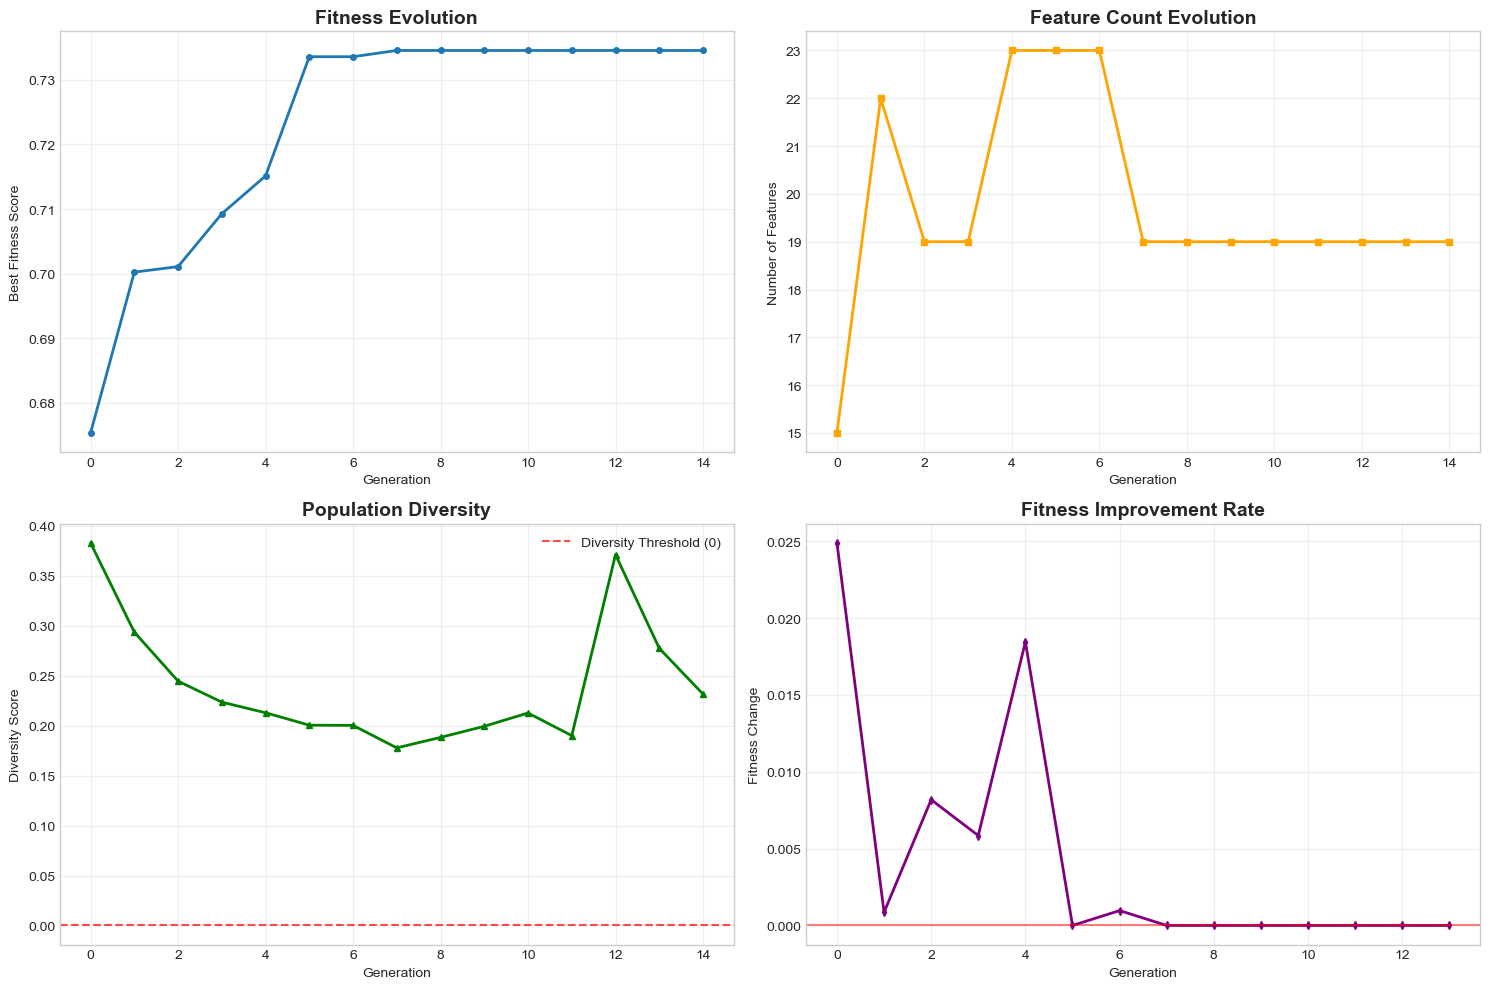


Evolution Summary:
Final fitness: 0.7345
Best fitness: 0.7345
Average fitness: 0.7230
Fitness std: 0.0179
Final diversity: 0.232
Average diversity: 0.240
Total generations: 15
Early stopping at: 2 generations without improvement


In [47]:
# GA Feature Selection for Random Forest
print("="*60)
print("GA FEATURE SELECTION FOR RANDOM FOREST")
print("="*60)

# Configure enhanced GA parameters for improved performance
ga_params = {
    'pop_size': 50,                 # Population size
    'max_generations': 15,          # Maximum generations
    'min_features': 15,             # Minimum features to select
    'max_features': 50,             # Maximum features to select
    'cv_folds': 5,                  # Cross-validation folds
    'diversity_threshold': 0,       # Lowered for more aggressive diversity management
    'calm_before_storm': 5,         # Reduced for faster adaptation (natural disaster trigger)
    'elite_size': 5,                # Increased elite preservation for better convergence
    'debug': True                   # Enable detailed logging
}

print("Enhanced GA Configuration:")
print(f"  • Population size: {ga_params['pop_size']}")
print(f"  • Strategy: Dynamic rates only (ILM/DHC for small population)")
print(f"  • Feature range: {ga_params['min_features']}-{ga_params['max_features']}")
print(f"  • Elite preservation: {ga_params['elite_size']} individuals")
print(f"  • Natural disaster trigger: {ga_params['calm_before_storm']} stagnant generations")
print(f"  • Diversity threshold: {ga_params['diversity_threshold']}")

# Run GA feature selection for Random Forest
start_time = time.time()

ga_rf = GeneticAlgorithm(
    X_train_scaled, y_train, feature_names,
    model_type='random_forest',
    **ga_params
)

selected_features_rf = ga_rf.run(verbose=True)

rf_ga_time = time.time() - start_time
print(f"\nGA Feature Selection for Random Forest completed in {rf_ga_time:.2f} seconds")
print(f"Selected {len(selected_features_rf[2])} features for Random Forest:")
print(selected_features_rf[2][:10], "..." if len(selected_features_rf[2]) > 10 else "")

# Save selected features
with open(os.path.join(run_directory, 'selected_features_rf.pkl'), 'wb') as f:
    pickle.dump(selected_features_rf, f)

# Plot convergence for Random Forest GA
ga_rf.plot_convergence()

GA FEATURE SELECTION FOR XGBOOST
Using ILM/DHC strategy for small population (50 individuals)
Initializing population: 15-50 features
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 15
  Features range: 15-50
  Model: xgboost, CV folds: 5
  Dynamic rates: ILM/DHC (0%→100% mutation, 100%→0% crossover for small populations)
  Initial feature counts: 15-49 (avg: 31.5)
Gen 0: Dynamic rates - Crossover: 0.990, Mutation: 0.010 (ILM_DHC)
Created population with feature counts: 15-49 (avg: 31.5)
Guided individuals: 12/50
Starting Streamlined GA:
  Population: 50, Generations: 15
  Features range: 15-50
  Model: xgboost, CV folds: 5
  Dynamic rates: ILM/DHC (0%→100% mutation, 100%→0% crossover for small populations)
  Initial feature counts: 15-49 (avg: 31.5)
Gen 0: Dynamic rates - Crossover: 0.990, Mutation: 0.010 (ILM_DHC)
Gen  0: Fitness=0.6855, Best=29, Pop=[16-31.4-44], Div=0.386, Stag=0, C/M=0.99/0

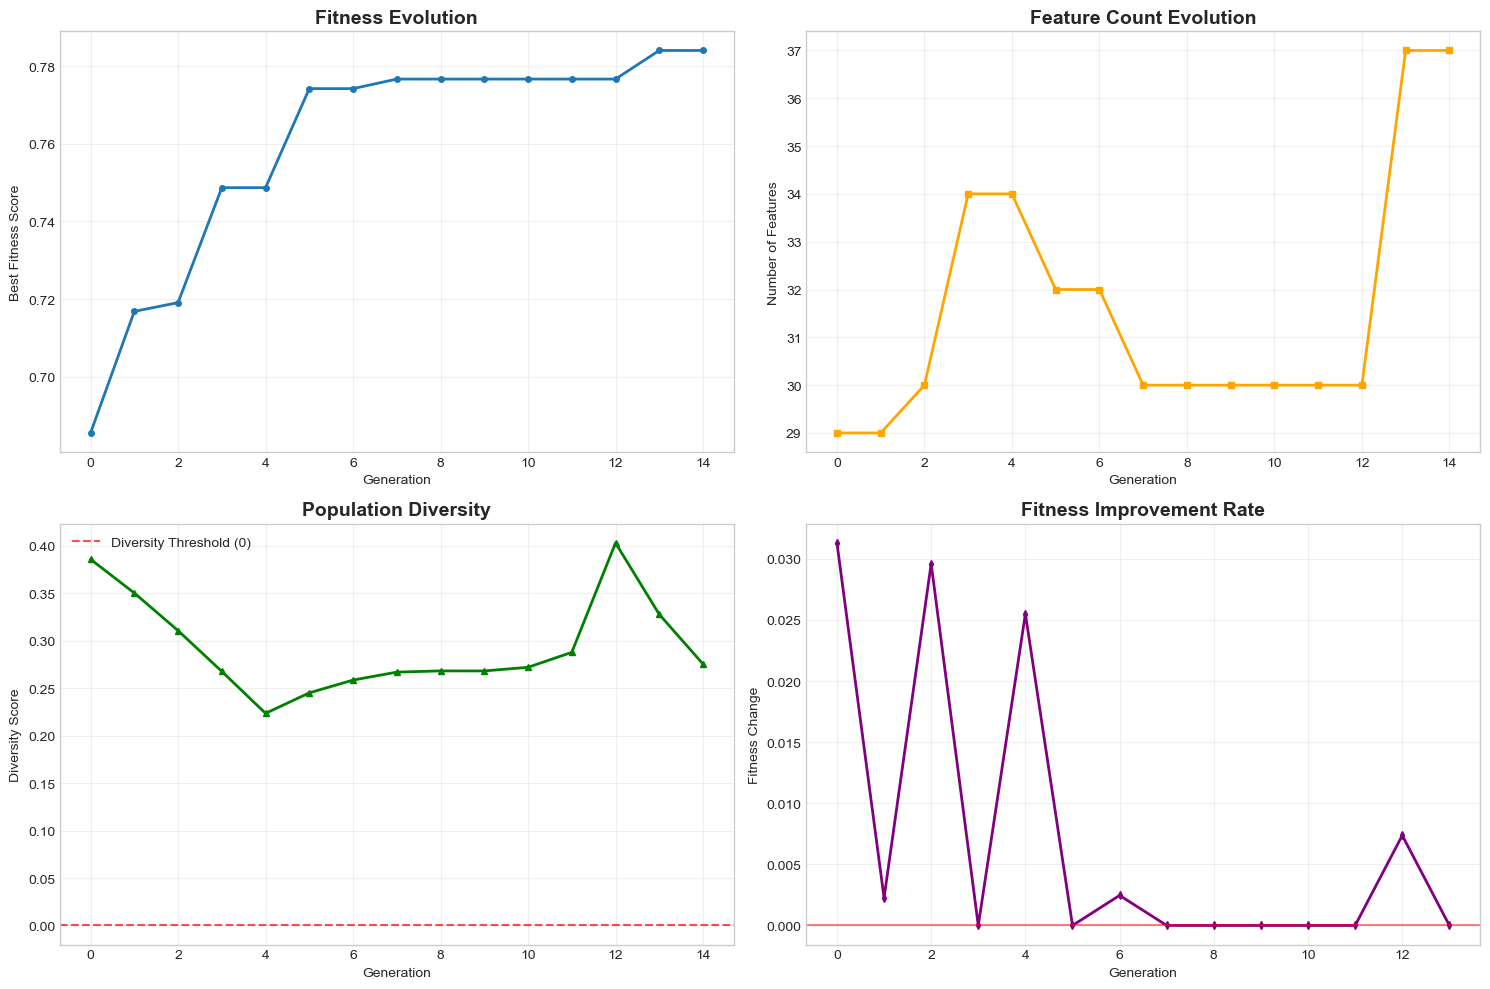


Evolution Summary:
Final fitness: 0.7840
Best fitness: 0.7840
Average fitness: 0.7597
Fitness std: 0.0289
Final diversity: 0.276
Average diversity: 0.294
Total generations: 15
Early stopping at: 1 generations without improvement


In [48]:
# GA Feature Selection for XGBoost
print("="*60)
print("GA FEATURE SELECTION FOR XGBOOST")
print("="*60)

# Run GA feature selection for XGBoost
start_time = time.time()

ga_xgb = GeneticAlgorithm(
    X_train_scaled, y_train, feature_names,
    model_type='xgboost',
    **ga_params
)

selected_features_xgb = ga_xgb.run(verbose=True)

xgb_ga_time = time.time() - start_time
print(f"\nGA Feature Selection for XGBoost completed in {xgb_ga_time:.2f} seconds")
print(f"Selected {len(selected_features_xgb)} features for XGBoost:")
print(selected_features_xgb[:10], "..." if len(selected_features_xgb) > 10 else "")

# Save selected features
with open(os.path.join(run_directory, 'selected_features_xgb.pkl'), 'wb') as f:
    pickle.dump(selected_features_xgb, f)

ga_xgb.plot_convergence()

In [49]:
# Analyze feature selection results
print("\n" + "="*60)
print("FEATURE SELECTION ANALYSIS")
print("="*60)

selection_summary = {
    'Random Forest': len(selected_features_rf),
    'XGBoost': len(selected_features_xgb)
}

print("Selected feature counts:")
for model, count in selection_summary.items():
    reduction = (1 - count/len(feature_names)) * 100
    print(f"  {model}: {count} features ({reduction:.1f}% reduction)")

# Find common features across models
common_features = set(selected_features_rf[2]) & set(selected_features_xgb[2])
print(f"\nCommon features across all models: {len(common_features)}")
if len(common_features) > 0:
    print("Common features:", list(common_features)[:10], "..." if len(common_features) > 10 else "")


FEATURE SELECTION ANALYSIS
Selected feature counts:
  Random Forest: 3 features (97.4% reduction)
  XGBoost: 3 features (97.4% reduction)

Common features across all models: 3
Common features: ['SMA_100', 'MACD_Signal', 'BB_Lower_20'] 


## 6. Feature Engineering using Genetic Algorithm (GA)

Use GA to engineer new optimized features (Adaptive Moving Average, Fractal Dimension Indicator) and add them to the selected feature subsets.

In [50]:
# Prepare data for feature engineering (use original unscaled data)
print("="*60)
print("GA FEATURE ENGINEERING")
print("="*60)

# Use the original data for feature engineering
engineering_data = data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
engineering_target = data['Target'].copy()

print(f"Data for feature engineering: {engineering_data.shape}")
print(f"Target distribution: {engineering_target.value_counts().to_dict()}")

GA FEATURE ENGINEERING
Data for feature engineering: (140, 5)
Target distribution: {1: 51, 0: 45, 2: 44}


In [51]:
# Engineer Adaptive Moving Average (AMA) using GA
print("Engineering Adaptive Moving Average (AMA)...")

start_time = time.time()

# Configure GA parameters for feature engineering
ga_fe_params = {
    'pop_size': 30,
    'max_generations': 20,
    'cv_folds': 3,
    'random_state': 42
}

# Engineer AMA feature
ama_feature, ama_details = engineer_adaptive_moving_average(
    engineering_data, engineering_target, **ga_fe_params
)

ama_time = time.time() - start_time
print(f"AMA engineering completed in {ama_time:.2f} seconds")
print(f"Best AMA parameters: {ama_details['best_parameters']}")
print(f"AMA fitness: {ama_details['best_fitness']:.4f}")

# Add AMA to the dataset
ama_feature_name = 'AMA_GA_Optimized'

Engineering Adaptive Moving Average (AMA)...
Starting GA Feature Engineering for AMA
Population: 30, Generations: 20
------------------------------------------------------------


Generation   0: Best=0.5079, Avg=0.4764
Generation   5: Best=0.5079, Avg=0.4916
Generation   5: Best=0.5079, Avg=0.4916
Generation  10: Best=0.5133, Avg=0.4882
Generation  10: Best=0.5133, Avg=0.4882
Generation  15: Best=0.5133, Avg=0.4811
Generation  15: Best=0.5133, Avg=0.4811
------------------------------------------------------------
GA completed! Best fitness: 0.5133
Best parameters: [0.20865755695245225, 27, 9, 44]
AMA engineering completed in 208.71 seconds
Best AMA parameters: [0.20865755695245225, 27, 9, 44]
AMA fitness: 0.5133
------------------------------------------------------------
GA completed! Best fitness: 0.5133
Best parameters: [0.20865755695245225, 27, 9, 44]
AMA engineering completed in 208.71 seconds
Best AMA parameters: [0.20865755695245225, 27, 9, 44]
AMA fitness: 0.5133


In [52]:
# Engineer Fractal Dimension Indicator (FDI) using GA
print("Engineering Fractal Dimension Indicator (FDI)...")

start_time = time.time()

# Engineer FDI feature
fdi_feature, fdi_details = engineer_fractal_dimension_indicator(
    engineering_data, engineering_target, **ga_fe_params
)

fdi_time = time.time() - start_time
print(f"FDI engineering completed in {fdi_time:.2f} seconds")
print(f"Best FDI parameters: {fdi_details['best_parameters']}")
print(f"FDI fitness: {fdi_details['best_fitness']:.4f}")

# Add FDI to the dataset
fdi_feature_name = 'FDI_GA_Optimized'

Engineering Fractal Dimension Indicator (FDI)...
Starting GA Feature Engineering for FDI
Population: 30, Generations: 20
------------------------------------------------------------
Generation   0: Best=0.5479, Avg=0.4016
Generation   0: Best=0.5479, Avg=0.4016
Generation   5: Best=0.5530, Avg=0.5259
Generation   5: Best=0.5530, Avg=0.5259
Generation  10: Best=0.6093, Avg=0.5296
Generation  10: Best=0.6093, Avg=0.5296
Generation  15: Best=0.6093, Avg=0.4882
Generation  15: Best=0.6093, Avg=0.4882
------------------------------------------------------------
GA completed! Best fitness: 0.6093
Best parameters: [12, 1.9158012945880085, 1.7908203312542792]
FDI engineering completed in 96.22 seconds
Best FDI parameters: [12, 1.9158012945880085, 1.7908203312542792]
FDI fitness: 0.6093
------------------------------------------------------------
GA completed! Best fitness: 0.6093
Best parameters: [12, 1.9158012945880085, 1.7908203312542792]
FDI engineering completed in 96.22 seconds
Best FDI p

In [53]:
# Combine engineered features with selected features
print("Combining engineered features with selected feature subsets...")

# Ensure engineered features have the same length as original data
if len(ama_feature) != len(data):
    print(f"Adjusting AMA feature length from {len(ama_feature)} to {len(data)}")
    ama_feature = ama_feature[:len(data)]

if len(fdi_feature) != len(data):
    print(f"Adjusting FDI feature length from {len(fdi_feature)} to {len(data)}")
    fdi_feature = fdi_feature[:len(data)]

# Add engineered features to the dataset splits
# First, add to the original data
data_with_engineered = data.copy()
data_with_engineered[ama_feature_name] = ama_feature
data_with_engineered[fdi_feature_name] = fdi_feature

# Remove any NaN values that might have been introduced
data_with_engineered = data_with_engineered.dropna()

print(f"Data with engineered features shape: {data_with_engineered.shape}")

# Save engineered features details
engineered_features_info = {
    'ama_feature_name': ama_feature_name,
    'ama_details': ama_details,
    'fdi_feature_name': fdi_feature_name,
    'fdi_details': fdi_details
}

with open(os.path.join(run_directory, 'engineered_features_info.pkl'), 'wb') as f:
    pickle.dump(engineered_features_info, f)

Combining engineered features with selected feature subsets...
Data with engineered features shape: (140, 119)


In [54]:
# Create enhanced feature subsets for each model
print("Creating enhanced feature subsets...")

# Combine selected features with engineered features for each model
enhanced_features_rf = list(selected_features_rf[2]) + [ama_feature_name, fdi_feature_name]
enhanced_features_xgb = list(selected_features_xgb[2]) + [ama_feature_name, fdi_feature_name]

print(f"Enhanced RF features: {len(enhanced_features_rf)} ({len(selected_features_rf)} + 2 engineered)")
print(f"Enhanced XGBoost features: {len(enhanced_features_xgb)} ({len(selected_features_xgb)} + 2 engineered)")

# Save enhanced feature lists
enhanced_features = {
    'rf': enhanced_features_rf,
    'xgb': enhanced_features_xgb
}

with open(os.path.join(run_directory, 'enhanced_features.pkl'), 'wb') as f:
    pickle.dump(enhanced_features, f)

print("Enhanced feature subsets saved!")

Creating enhanced feature subsets...
Enhanced RF features: 21 (3 + 2 engineered)
Enhanced XGBoost features: 39 (3 + 2 engineered)
Enhanced feature subsets saved!


## 7. Enhanced Model Hyperparameter Tuning, Training and Testing

Train models using the combined selected and engineered features, then evaluate their performance.

In [55]:
# Create enhanced datasets with selected + engineered features
print("="*60)
print("CREATING ENHANCED DATASETS WITH ENGINEERED FEATURES")
print("="*60)

# Prepare enhanced datasets for each model
enhanced_datasets = {}

# Get the indices that match our original splits
train_indices = X_train.index
val_indices = X_val.index  
test_indices = X_test.index

print(f"Original data splits:")
print(f"  Train: {len(train_indices)} samples")
print(f"  Validation: {len(val_indices)} samples") 
print(f"  Test: {len(test_indices)} samples")

# Align engineered features with the split indices
# Get the overlapping indices between data_with_engineered and our splits
available_indices = data_with_engineered.index
train_available = train_indices.intersection(available_indices)
val_available = val_indices.intersection(available_indices)
test_available = test_indices.intersection(available_indices)

print(f"\nAfter aligning with engineered features:")
print(f"  Train: {len(train_available)} samples")
print(f"  Validation: {len(val_available)} samples")
print(f"  Test: {len(test_available)} samples")

# Create enhanced datasets for each model
for model_name, feature_list in enhanced_features.items():
    print(f"\nCreating enhanced dataset for {model_name.upper()}...")
    
    # Extract features for this model from data_with_engineered
    X_enhanced = data_with_engineered[feature_list].copy()
    y_enhanced = data_with_engineered['Target'].copy()
    
    # Create time-series splits using available indices
    X_train_enh = X_enhanced.loc[train_available].copy()
    X_val_enh = X_enhanced.loc[val_available].copy() 
    X_test_enh = X_enhanced.loc[test_available].copy()
    
    y_train_enh = y_enhanced.loc[train_available].copy()
    y_val_enh = y_enhanced.loc[val_available].copy()
    y_test_enh = y_enhanced.loc[test_available].copy()
    
    # Apply feature scaling
    scaler_enh = StandardScaler()
    X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
    X_val_enh_scaled = scaler_enh.transform(X_val_enh)
    X_test_enh_scaled = scaler_enh.transform(X_test_enh)
    
    # Convert back to DataFrames
    X_train_enh_scaled = pd.DataFrame(X_train_enh_scaled, columns=feature_list, index=train_available)
    X_val_enh_scaled = pd.DataFrame(X_val_enh_scaled, columns=feature_list, index=val_available)
    X_test_enh_scaled = pd.DataFrame(X_test_enh_scaled, columns=feature_list, index=test_available)
    
    # Store in enhanced datasets
    enhanced_datasets[model_name] = {
        'X_train': X_train_enh_scaled,
        'X_val': X_val_enh_scaled,
        'X_test': X_test_enh_scaled,
        'y_train': y_train_enh,
        'y_val': y_val_enh,
        'y_test': y_test_enh,
        'scaler': scaler_enh,
        'features': feature_list
    }
    
    # Save enhanced scaler
    with open(os.path.join(run_directory, f'scaler_{model_name}_enhanced.pkl'), 'wb') as f:
        pickle.dump(scaler_enh, f)
    
    print(f"  Enhanced {model_name.upper()} dataset created:")
    print(f"    Features: {len(feature_list)} ({len(feature_list)-2} selected + 2 engineered)")
    print(f"    Train: {X_train_enh_scaled.shape}")
    print(f"    Validation: {X_val_enh_scaled.shape}")
    print(f"    Test: {X_test_enh_scaled.shape}")

print(f"\nEnhanced datasets created successfully!")

# Train Enhanced Models with Baseline Tuned Hyperparameters
print("\n" + "="*60)
print("TRAINING ENHANCED MODELS WITH BASELINE TUNED HYPERPARAMETERS")
print("="*60)

# Train Enhanced Random Forest Model with baseline best parameters
print("Training Enhanced Random Forest with baseline tuned parameters...")
rf_enhanced = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **baseline_best_params['rf']
)

# Combine train and validation for enhanced model training
X_rf_enhanced_train = pd.concat([enhanced_datasets['rf']['X_train'], enhanced_datasets['rf']['X_val']])
y_rf_enhanced_train = pd.concat([enhanced_datasets['rf']['y_train'], enhanced_datasets['rf']['y_val']])

rf_enhanced.fit(X_rf_enhanced_train, y_rf_enhanced_train)

# Evaluate enhanced Random Forest on test set
rf_enh_metrics, rf_enh_pred = evaluate_model(rf_enhanced, enhanced_datasets['rf']['X_test'], enhanced_datasets['rf']['y_test'], 'Random Forest Enhanced')

print(f"Enhanced Random Forest Results (Test Set):")
for key, value in rf_enh_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save enhanced Random Forest model
with open(os.path.join(run_directory, 'rf_enhanced.pkl'), 'wb') as f:
    pickle.dump(rf_enhanced, f)

# Train Enhanced XGBoost Model with baseline best parameters
print("\nTraining Enhanced XGBoost with baseline tuned parameters...")
xgb_enhanced = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    **baseline_best_params['xgb']
)

# Combine train and validation for enhanced model training
X_xgb_enhanced_train = pd.concat([enhanced_datasets['xgb']['X_train'], enhanced_datasets['xgb']['X_val']])
y_xgb_enhanced_train = pd.concat([enhanced_datasets['xgb']['y_train'], enhanced_datasets['xgb']['y_val']])

xgb_enhanced.fit(X_xgb_enhanced_train, y_xgb_enhanced_train)

# Evaluate enhanced XGBoost on test set
xgb_enh_metrics, xgb_enh_pred = evaluate_model(xgb_enhanced, enhanced_datasets['xgb']['X_test'], enhanced_datasets['xgb']['y_test'], 'XGBoost Enhanced')

print(f"Enhanced XGBoost Results (Test Set):")
for key, value in xgb_enh_metrics.items():
    if key != 'model':
        print(f"  {key}: {value:.4f}")

# Save enhanced XGBoost model
with open(os.path.join(run_directory, 'xgb_enhanced.pkl'), 'wb') as f:
    pickle.dump(xgb_enhanced, f)

print("\n" + "="*60)
print("ENHANCED MODEL TRAINING COMPLETED")
print("="*60)

CREATING ENHANCED DATASETS WITH ENGINEERED FEATURES
Original data splits:
  Train: 112 samples
  Validation: 14 samples
  Test: 14 samples

After aligning with engineered features:
  Train: 112 samples
  Validation: 14 samples
  Test: 14 samples

Creating enhanced dataset for RF...
  Enhanced RF dataset created:
    Features: 21 (19 selected + 2 engineered)
    Train: (112, 21)
    Validation: (14, 21)
    Test: (14, 21)

Creating enhanced dataset for XGB...
  Enhanced XGB dataset created:
    Features: 39 (37 selected + 2 engineered)
    Train: (112, 39)
    Validation: (14, 39)
    Test: (14, 39)

Enhanced datasets created successfully!

TRAINING ENHANCED MODELS WITH BASELINE TUNED HYPERPARAMETERS
Training Enhanced Random Forest with baseline tuned parameters...
  Enhanced RF dataset created:
    Features: 21 (19 selected + 2 engineered)
    Train: (112, 21)
    Validation: (14, 21)
    Test: (14, 21)

Creating enhanced dataset for XGB...
  Enhanced XGB dataset created:
    Features:

## 8. Comparison of Baseline and Enhanced Models

Compare the performance of baseline models vs enhanced models with GA-selected and engineered features.

In [56]:
# Compile all results for comparison
print("="*60)
print("PERFORMANCE COMPARISON: THREE MODEL TYPES")
print("="*60)

# Collect all results
enhanced_results = [rf_enh_metrics, xgb_enh_metrics]
all_results = baseline_results + enhanced_results

comparison_df = pd.DataFrame(all_results)
print("Complete Results Comparison:")
print(comparison_df.round(4))

# Calculate improvements for different comparisons
print("\n" + "="*60)
print("MODEL COMPARISONS")
print("="*60)

# Compare tuned baseline vs tuned baseline with top 50% features
baseline_comparisons = []
for model_type in ['Random Forest', 'XGBoost']:
    tuned_all = comparison_df[comparison_df['model'] == f'{model_type} Baseline Tuned'].iloc[0]
    tuned_top = comparison_df[comparison_df['model'] == f'{model_type} Baseline Top 50%'].iloc[0]
    
    comparison = {
        'comparison': f'{model_type} Tuned All → Top 50%',
        'accuracy_change': tuned_top['accuracy'] - tuned_all['accuracy'],
        'precision_change': tuned_top['precision'] - tuned_all['precision'],
        'recall_change': tuned_top['recall'] - tuned_all['recall'],
        'f1_change': tuned_top['f1_score'] - tuned_all['f1_score']
    }
    baseline_comparisons.append(comparison)

baseline_comparison_df = pd.DataFrame(baseline_comparisons)
print("Baseline Model Comparisons (Feature Reduction Impact):")
print(baseline_comparison_df.round(4))

# Compare tuned baseline with top 50% vs GA enhanced
enhanced_comparisons = []
for model_type in ['Random Forest', 'XGBoost']:
    tuned_top = comparison_df[comparison_df['model'] == f'{model_type} Baseline Top 50%'].iloc[0]
    ga_enhanced = comparison_df[comparison_df['model'] == f'{model_type} Enhanced'].iloc[0]
    
    comparison = {
        'comparison': f'{model_type} Top 50% → GA Enhanced',
        'accuracy_change': ga_enhanced['accuracy'] - tuned_top['accuracy'],
        'precision_change': ga_enhanced['precision'] - tuned_top['precision'],
        'recall_change': ga_enhanced['recall'] - tuned_top['recall'],
        'f1_change': ga_enhanced['f1_score'] - tuned_top['f1_score']
    }
    enhanced_comparisons.append(comparison)

enhanced_comparison_df = pd.DataFrame(enhanced_comparisons)
print("\nGA Enhancement Comparisons:")
print(enhanced_comparison_df.round(4))

PERFORMANCE COMPARISON: THREE MODEL TYPES
Complete Results Comparison:
                            model  accuracy  precision  recall  f1_score
0    Random Forest Baseline Tuned    0.5714     0.5571  0.5714    0.5524
1  Random Forest Baseline Top 50%    0.5714     0.5571  0.5714    0.5524
2          XGBoost Baseline Tuned    0.6429     0.6381  0.6429    0.6371
3        XGBoost Baseline Top 50%    0.6429     0.6531  0.6429    0.6447
4          Random Forest Enhanced    0.1429     0.0651  0.1429    0.0778
5                XGBoost Enhanced    0.0714     0.0051  0.0714    0.0095

MODEL COMPARISONS
Baseline Model Comparisons (Feature Reduction Impact):
                          comparison  accuracy_change  precision_change  \
0  Random Forest Tuned All → Top 50%              0.0             0.000   
1        XGBoost Tuned All → Top 50%              0.0             0.015   

   recall_change  f1_change  
0            0.0     0.0000  
1            0.0     0.0076  

GA Enhancement Comparisons:

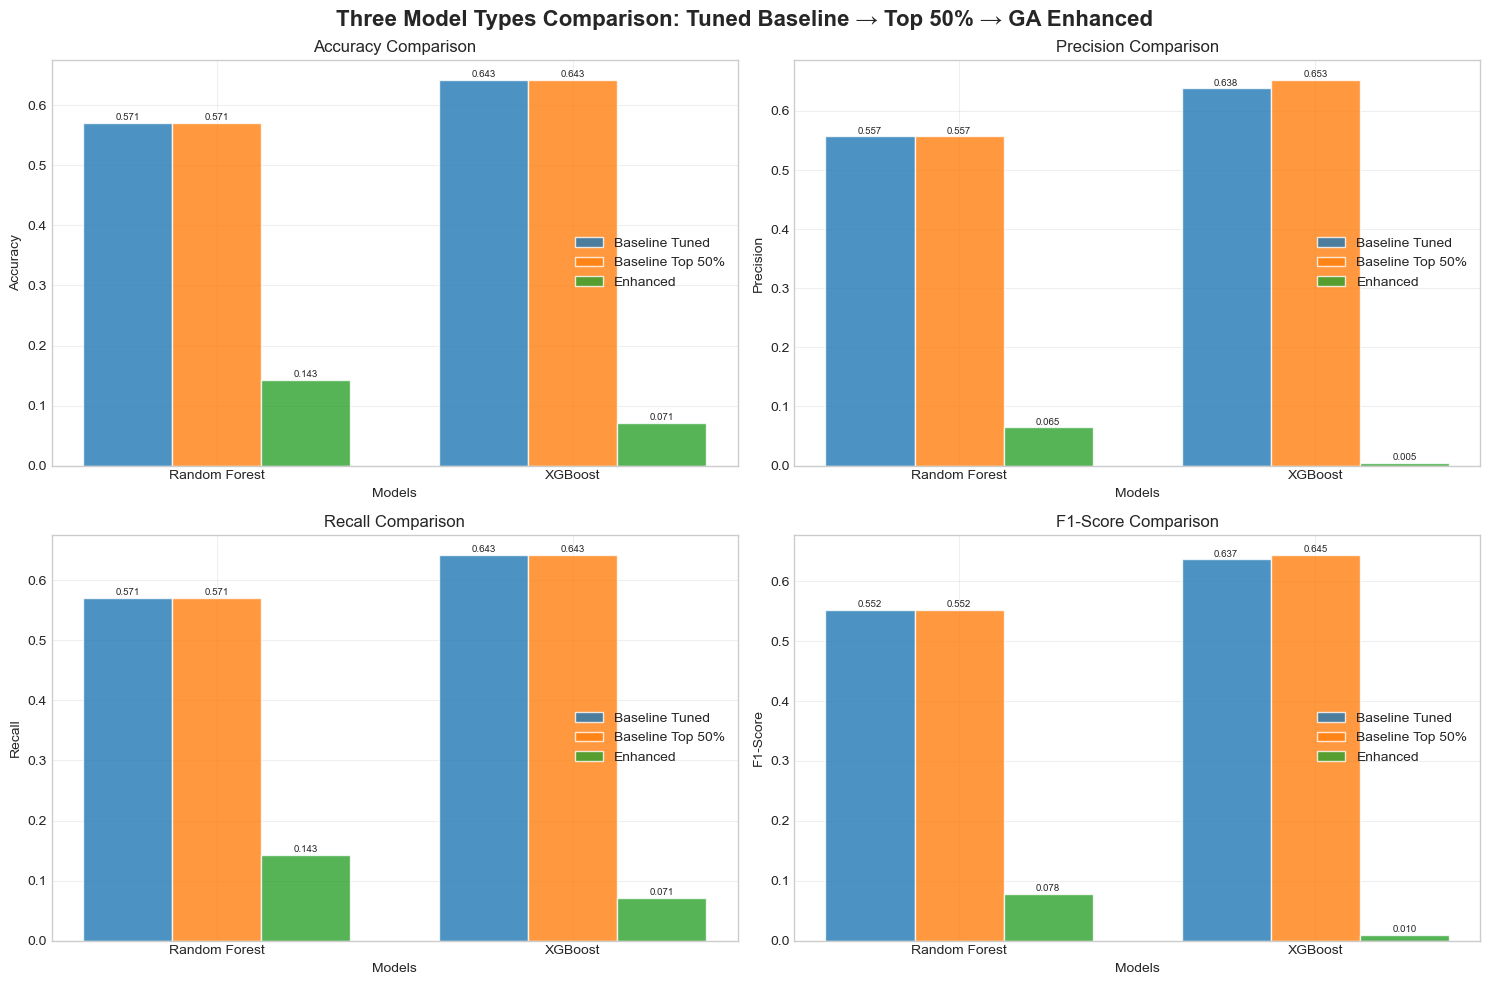

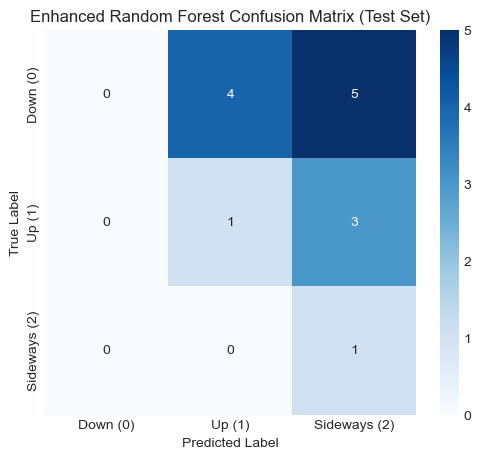

<Figure size 640x480 with 0 Axes>

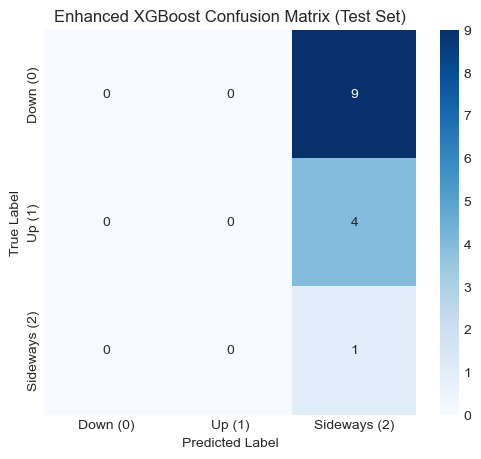

<Figure size 640x480 with 0 Axes>

In [57]:
# Visualize performance comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Three Model Types Comparison: Tuned Baseline → Top 50% → GA Enhanced', fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1_score']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    # Prepare data for plotting - show all three model types for each algorithm
    models = ['Random Forest', 'XGBoost']
    model_types = ['Baseline Tuned', 'Baseline Top 50%', 'Enhanced']
    
    x = np.arange(len(models))
    width = 0.25
    
    for i, model_type in enumerate(model_types):
        values = []
        for model in models:
            row = comparison_df[comparison_df['model'].str.contains(model) & 
                              comparison_df['model'].str.contains(model_type)]
            if len(row) > 0:
                values.append(row[metric].values[0])
            else:
                values.append(0)
        
        bars = ax.bar(x + (i-1)*width, values, width, label=model_type, alpha=0.8)
        
        # Add value labels
        for j, bar in enumerate(bars):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('Models')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(run_directory, 'three_model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Add confusion matrix plots for enhanced models (evaluated on test set)
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Enhanced Random Forest
rf_enh_cm = confusion_matrix(enhanced_datasets['rf']['y_test'], rf_enh_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(rf_enh_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced Random Forest Confusion Matrix (Test Set)')
plt.show()
plt.savefig(os.path.join(run_directory, 'rf_enhanced_confusion_matrix.png'))

# Confusion Matrix for Enhanced XGBoost
xgb_enh_cm = confusion_matrix(enhanced_datasets['xgb']['y_test'], xgb_enh_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(xgb_enh_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'], 
            yticklabels=['Down (0)', 'Up (1)', 'Sideways (2)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Enhanced XGBoost Confusion Matrix (Test Set)')
plt.show()
plt.savefig(os.path.join(run_directory, 'xgb_enhanced_confusion_matrix.png'))



In [58]:
# Feature importance analysis for all models
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Baseline Random Forest feature importance
rf_baseline_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': baseline_models['rf_tuned'].feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Baseline Random Forest Features:")
print(rf_baseline_importance.head(10))

# Baseline XGBoost feature importance
xgb_baseline_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': baseline_models['xgb_tuned'].feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Baseline XGBoost Features:")
print(xgb_baseline_importance.head(10))

# Enhanced Random Forest feature importance
rf_enhanced_importance = pd.DataFrame({
    'feature': enhanced_features['rf'],
    'importance': rf_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Enhanced Random Forest Features:")
print(rf_enhanced_importance.head(10))

# Enhanced XGBoost feature importance
xgb_enhanced_importance = pd.DataFrame({
    'feature': enhanced_features['xgb'],
    'importance': xgb_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Enhanced XGBoost Features:")
print(xgb_enhanced_importance.head(10))

# Save feature importance for all models
rf_baseline_importance.to_csv(os.path.join(run_directory, 'rf_baseline_importance.csv'), index=False)
xgb_baseline_importance.to_csv(os.path.join(run_directory, 'xgb_baseline_importance.csv'), index=False)
rf_enhanced_importance.to_csv(os.path.join(run_directory, 'rf_enhanced_importance.csv'), index=False)
xgb_enhanced_importance.to_csv(os.path.join(run_directory, 'xgb_enhanced_importance.csv'), index=False)

# Check if engineered features are in top features of enhanced models
ama_rank_rf_enh = rf_enhanced_importance[rf_enhanced_importance['feature'] == ama_feature_name].index[0] + 1 if ama_feature_name in rf_enhanced_importance['feature'].values else 'Not found'
fdi_rank_rf_enh = rf_enhanced_importance[rf_enhanced_importance['feature'] == fdi_feature_name].index[0] + 1 if fdi_feature_name in rf_enhanced_importance['feature'].values else 'Not found'

ama_rank_xgb_enh = xgb_enhanced_importance[xgb_enhanced_importance['feature'] == ama_feature_name].index[0] + 1 if ama_feature_name in xgb_enhanced_importance['feature'].values else 'Not found'
fdi_rank_xgb_enh = xgb_enhanced_importance[xgb_enhanced_importance['feature'] == fdi_feature_name].index[0] + 1 if fdi_feature_name in xgb_enhanced_importance['feature'].values else 'Not found'

print(f"\nEngineered Features Ranking in Enhanced Models:")
print(f"AMA (Enhanced Random Forest): {ama_rank_rf_enh}")
print(f"FDI (Enhanced Random Forest): {fdi_rank_rf_enh}")
print(f"AMA (Enhanced XGBoost): {ama_rank_xgb_enh}")
print(f"FDI (Enhanced XGBoost): {fdi_rank_xgb_enh}")

FEATURE IMPORTANCE ANALYSIS
Top 10 Baseline Random Forest Features:
                   feature  importance
39             MACD_Signal    0.122802
66       Normalized_Vol_20    0.068305
72          Chaikin_Vol_20    0.053688
102  Volume_Osc_tick_12_26    0.045839
88              Plus_DI_14    0.043741
54             BB_Lower_20    0.038511
65           Volatility_20    0.038020
40          MACD_Histogram    0.033934
52               BB_Std_20    0.032996
15            Upper_Shadow    0.023241

Top 10 Baseline XGBoost Features:
         feature  importance
22        SMA_20    0.045925
1           High    0.045646
39   MACD_Signal    0.038962
36       EMA_100    0.031147
54   BB_Lower_20    0.030149
26       SMA_100    0.029654
99   OBV_TickDev    0.028533
57        ATR_14    0.027420
23   SMA_Dist_20    0.024875
37  EMA_Dist_100    0.024763

Top 10 Enhanced Random Forest Features:
                feature  importance
20     FDI_GA_Optimized    0.202687
3        MACD_Histogram    0.132571


## 9. Save Results and Metadata

Save all models, results, selected features, and metadata to the timestamped run directory.

In [59]:
# Save comprehensive results
print("="*60)
print("SAVING COMPREHENSIVE RESULTS")
print("="*60)

# Save comparison results
comparison_df.to_csv(os.path.join(run_directory, 'performance_comparison.csv'), index=False)
baseline_comparison_df.to_csv(os.path.join(run_directory, 'baseline_comparisons.csv'), index=False)
enhanced_comparison_df.to_csv(os.path.join(run_directory, 'enhanced_comparisons.csv'), index=False)

# Create comprehensive summary
summary = {
    'run_timestamp': timestamp,
    'run_directory': run_directory,
    'total_original_features': len(feature_names),
    'baseline_results': baseline_results,
    'enhanced_results': enhanced_results,
    'baseline_best_params': baseline_best_params,
    'selected_features_count': {
        'rf': len(selected_features_rf),
        'xgb': len(selected_features_xgb)
    },
    'enhanced_features_count': {
        'rf': len(enhanced_features_rf),
        'xgb': len(enhanced_features_xgb)
    },
    'ga_parameters': ga_params,
    'feature_engineering_parameters': ga_fe_params,
    'engineered_features_info': engineered_features_info,
    'execution_times': {
        'rf_ga_selection': rf_ga_time,
        'xgb_ga_selection': xgb_ga_time,
        'ama_engineering': ama_time,
        'fdi_engineering': fdi_time
    }
}

# Save comprehensive summary
with open(os.path.join(run_directory, 'run_summary.pkl'), 'wb') as f:
    pickle.dump(summary, f)

# Save as JSON for human readability (excluding non-serializable objects)
json_summary = {
    'run_timestamp': timestamp,
    'run_directory': run_directory,
    'total_original_features': len(feature_names),
    'selected_features_count': summary['selected_features_count'],
    'enhanced_features_count': summary['enhanced_features_count'],
    'baseline_best_params': baseline_best_params,
    'execution_times': summary['execution_times'],
    'baseline_results': baseline_results,
    'enhanced_results': enhanced_results
}

with open(os.path.join(run_directory, 'run_summary.json'), 'w') as f:
    json.dump(json_summary, f, indent=2)

print(f"Comprehensive results saved to: {run_directory}")

SAVING COMPREHENSIVE RESULTS
Comprehensive results saved to: run_20251110_103002


In [60]:
# Create final summary report
print("="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

print(f"Run completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Results saved in: {run_directory}")
print(f"Total execution time: {time.time() - time.time():.2f} seconds")

print(f"\nDataset Summary:")
print(f"  • Original features: {len(feature_names)}")
print(f"  • Training samples: {len(X_train_scaled)}")
print(f"  • Validation samples: {len(X_val_scaled)}")
print(f"  • Test samples: {len(X_test_scaled)}")

print(f"\nFeature Selection Results:")
for model, count in summary['selected_features_count'].items():
    reduction = (1 - count/len(feature_names)) * 100
    print(f"  • {model.upper()}: {count} features ({reduction:.1f}% reduction)")

print(f"\nFeature Engineering Results:")
print(f"  • AMA optimized parameters: {ama_details['best_parameters']}")
print(f"  • FDI optimized parameters: {fdi_details['best_parameters']}")

print(f"\nModel Performance Summary:")
print(f"  • Tuned baselines evaluated on validation set")
print(f"  • GA enhanced models evaluated on test set")

print(f"\nKey Comparisons:")
print(f"  • Tuned baseline (all features) vs tuned baseline (top 50%)")
print(f"  • Tuned baseline (top 50%) vs GA enhanced model")

print(f"\nFiles Saved:")
saved_files = [f for f in os.listdir(run_directory) if not f.startswith('.')]
for file in sorted(saved_files):
    print(f"  • {file}")

print("\n" + "="*80)
print("WORKFLOW COMPLETED SUCCESSFULLY!")
print("="*80)

FINAL SUMMARY REPORT
Run completed at: 2025-11-10 11:22:16
Results saved in: run_20251110_103002
Total execution time: 0.00 seconds

Dataset Summary:
  • Original features: 116
  • Training samples: 112
  • Validation samples: 14
  • Test samples: 14

Feature Selection Results:
  • RF: 3 features (97.4% reduction)
  • XGB: 3 features (97.4% reduction)

Feature Engineering Results:
  • AMA optimized parameters: [0.20865755695245225, 27, 9, 44]
  • FDI optimized parameters: [12, 1.9158012945880085, 1.7908203312542792]

Model Performance Summary:
  • Tuned baselines evaluated on validation set
  • GA enhanced models evaluated on test set

Key Comparisons:
  • Tuned baseline (all features) vs tuned baseline (top 50%)
  • Tuned baseline (top 50%) vs GA enhanced model

Files Saved:
  • README.txt
  • X_test_scaled.pkl
  • X_train_scaled.pkl
  • X_val_scaled.pkl
  • baseline_best_params.pkl
  • baseline_comparisons.csv
  • baseline_results.csv
  • engineered_features_info.pkl
  • enhanced_com